In [ ]:
# Baseline: Always predict the mean of the training data
y_baseline_value = y_train.mean()
y_baseline_pred_eval = np.full_like(y_eval, y_baseline_value)
mse_baseline_eval = calculate_mse(y_eval, y_baseline_pred_eval)

print(f'[Trained Model]   MSE (Eval): {mse_trained:.2f}')
print(f'[Baseline (Mean)] MSE (Eval): {mse_baseline_eval:.2f}')

# 1. Visualize Baseline (Full Evaluation Set)
plt.figure(figsize=(6, 6))
plt.scatter(X_eval, y_eval, color=color_palette['green'], marker='*', alpha=0.7, s=100, label='Evaluation data')
plt.axhline(y=y_baseline_value, color=color_palette['blue'], linestyle='--', linewidth=3, label='Baseline Prediction (Mean)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

# 2. Visualize Baseline (Sampled 10 points)
np.random.seed(42)
sample_indices = np.random.choice(len(y_eval), 10, replace=False)
X_sample = X_eval[sample_indices]
y_sample = y_eval[sample_indices]

plt.figure(figsize=(6, 6))
plt.scatter(X_sample, y_sample, color=color_palette['green'], s=150, marker='*', label='Evaluation data')
plt.axhline(y=y_baseline_value, color=color_palette['blue'], linestyle='--', linewidth=3, label='Baseline Prediction (Mean)')

# Residuals to the mean
for xi, yi in zip(X_sample, y_sample):
    plt.plot([xi, xi], [yi, y_baseline_value], color=color_palette['gray'], linestyle='--', linewidth=1.5, alpha=0.8)

plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

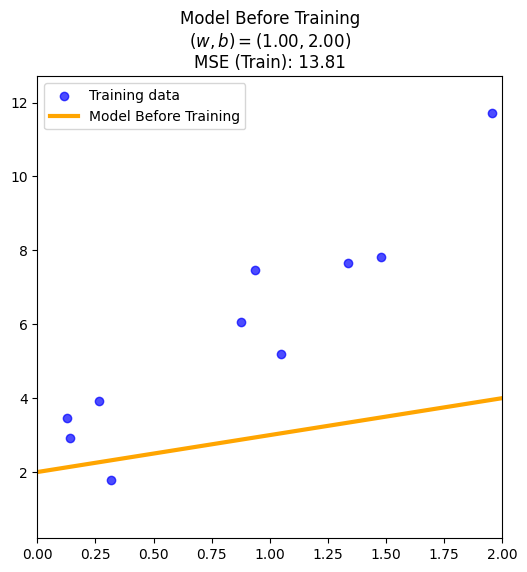

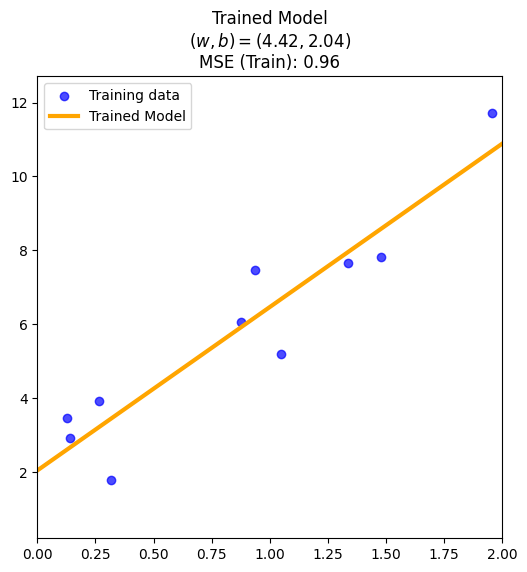

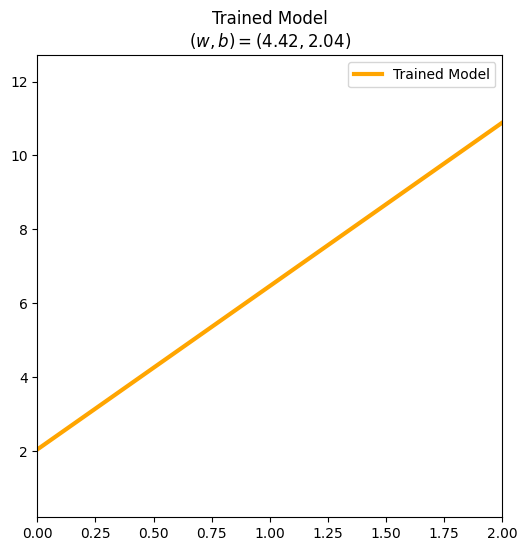

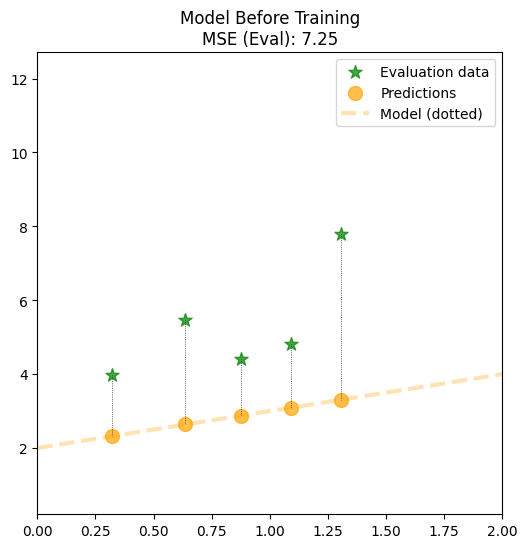

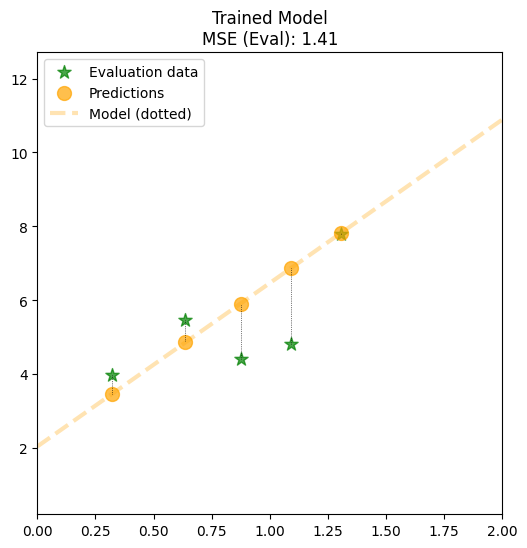

In [1]:
# Define standard color palette
color_palette = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "light_light_blue": "#E0FFFF",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080",
}

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Function for the true relationship
def true_function(X):
    return 2 + 4 * X

# Generate synthetic data
np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = true_function(X) + np.random.randn(100, 1)

# Split the data using train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=10, random_state=42)
X_eval, _, y_eval, _ = train_test_split(X_temp, y_temp, train_size=5, random_state=42)  # Fewer eval points

# Model A (Before Training)
model_before_training = LinearRegression()
model_before_training.coef_ = np.array([[1]])
model_before_training.intercept_ = np.array([2])
model_before_training.fit_intercept = False
y_pred_before_training = model_before_training.predict(X_eval)

# Model B (Trained Model)
trained_model = LinearRegression()
trained_model.fit(X_train, y_train)
y_pred_trained = trained_model.predict(X_eval)

# Function for plotting
def plot_model(title, X, y, y_pred, model_line, mse, filename, xlim, ylim):
    plt.figure(figsize=(6, 6))
    plt.scatter(X, y, color=color_palette["green"], marker="*", alpha=0.7, s=100, label="Evaluation data")  # Larger stars, 70% transparent
    plt.scatter(X, y_pred, color=color_palette["orange"], alpha=0.7, s=100, label="Predictions")  # Larger prediction points
    plt.plot(model_line[0], model_line[1], color=color_palette["orange"], linestyle="--", linewidth=3, alpha=0.3, label="Model (dotted)")  # 30% transparent line
    for x, y_true, y_pred_val in zip(X, y, y_pred):
        plt.plot([x, x], [y_true, y_pred_val], color="black", linestyle=":", linewidth=0.5)
    plt.title(f"{title}\nMSE (Eval): {mse:.2f}")
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.legend()
    plt.savefig(filename, bbox_inches="tight", pad_inches=0)
    plt.show()

# Calculate MSE
def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Determine consistent xlim and ylim
xlim = [0, 2]
ylim = [np.min(y) - 1, np.max(y) + 1]

# Calculate training MSE
mse_train_before_training = calculate_mse(y_train, model_before_training.predict(X_train))
mse_train_trained_model = calculate_mse(y_train, trained_model.predict(X_train))

# Plotting training models
X_plot = np.array([[0], [2]])
model_before_training_line = (X_plot, model_before_training.predict(X_plot))
trained_model_line = (X_plot, trained_model.predict(X_plot))

plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, color=color_palette["blue"], label="Training data", alpha=0.7)  # 70% transparency
plt.plot(model_before_training_line[0], model_before_training_line[1], color=color_palette["orange"], linewidth=3, label="Model Before Training")
    plt.title(
    f"Model Before Training\n"
    f"$(w, b) = ({np.array(model_before_training.coef_).item():.2f}, {float(np.array(model_before_training.intercept_).flatten()[0]):.2f})$\n"
    f"MSE (Train): {mse_train_before_training:.2f}"
)
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.savefig("model_before_training_train.png", bbox_inches="tight", pad_inches=0)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, color=color_palette["blue"], label="Training data", alpha=0.7)  # 70% transparency
plt.plot(trained_model_line[0], trained_model_line[1], color=color_palette["orange"], linewidth=3, label="Trained Model")
    plt.title(
    f"Trained Model\n"
    f"$(w, b) = ({np.array(trained_model.coef_).item():.2f}, {float(np.array(trained_model.intercept_).flatten()[0]):.2f})$\n"
    f"MSE (Train): {mse_train_trained_model:.2f}"
)
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.savefig("trained_model_train.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Trained Model
plt.figure(figsize=(6, 6))
plt.plot(trained_model_line[0], trained_model_line[1], color=color_palette["orange"], linewidth=3, label="Trained Model")
    plt.title(
    f"Trained Model\n"
    f"$(w, b) = ({np.array(trained_model.coef_).item():.2f}, {float(np.array(trained_model.intercept_).flatten()[0]):.2f})$"
)
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.savefig("trained_model.png", bbox_inches="tight", pad_inches=0)
plt.show()

# Evaluation Data Plots
mse_eval_before_training = calculate_mse(y_eval, y_pred_before_training)
mse_eval_trained_model = calculate_mse(y_eval, y_pred_trained)

plot_model(
    "Model Before Training",
    X_eval,
    y_eval,
    y_pred_before_training,
    model_before_training_line,
    mse_eval_before_training,
    "model_before_training_eval.png",
    xlim,
    ylim,
)

plot_model(
    "Trained Model",
    X_eval,
    y_eval,
    y_pred_trained,
    trained_model_line,
    mse_eval_trained_model,
    "trained_model_eval.png",
    xlim,
    ylim,
)

In [ ]:
# Baseline: Always predict the mean of the training data
y_baseline_value = y_train.mean()
y_baseline_pred_eval = np.full_like(y_eval, y_baseline_value)
mse_baseline_eval = calculate_mse(y_eval, y_baseline_pred_eval)
print(f'[Baseline (Mean)] MSE (Eval): {mse_baseline_eval:.2f}')

# Visualize Baseline
plt.figure(figsize=(6, 6))
plt.scatter(X_eval, y_eval, color=color_palette['green'], marker='*', alpha=0.7, s=100, label='Evaluation data')
plt.axhline(y=y_baseline_value, color=color_palette['blue'], linestyle='--', linewidth=3, label='Baseline Prediction (Mean)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()

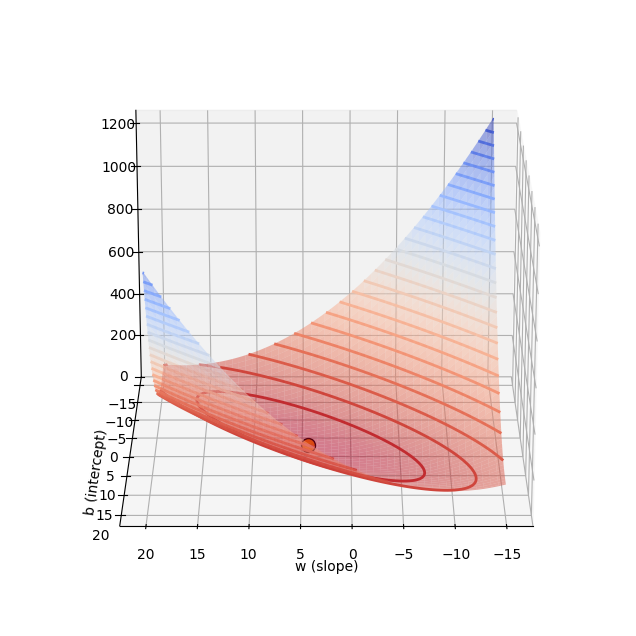

In [2]:
# -----------------------------------------
# Original Color Palette
# -----------------------------------------


# Create a grid of parameter values
w_range = np.linspace(-15, 20, 100)
b_range = np.linspace(-15, 20, 100)
W, B = np.meshgrid(w_range, b_range)

# Calculate MSE for each parameter combination
Z = np.zeros_like(W)
for i in range(len(w_range)):
    for j in range(len(b_range)):
        w = w_range[i]
        b = b_range[j]
        y_pred = w * X_train + b
        Z[j, i] = np.mean((y_train - y_pred) ** 2)

# Create 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface with custom colors
surface = ax.plot_surface(W, B, Z, cmap='coolwarm_r', alpha=0.5, edgecolor='none')

# Add contour lines with custom colors
contours = ax.contour3D(W, B, Z, levels=30, cmap='coolwarm_r', linewidths=2)

# Mark the optimal point (trained model parameters)
optimal_w = np.array(trained_model.coef_).item()
optimal_b = float(np.array(trained_model.intercept_).flatten()[0])
optimal_mse = calculate_mse(y_train, trained_model.predict(X_train))

ax.scatter(optimal_w, optimal_b, optimal_mse, color=color_palette["dark_orange"], s=100, label='Optimal Point', edgecolors='k', linewidths=1)

# Adjust view distance and angle
ax.view_init(elev=20, azim=90)
ax.dist = 12

# Labels and title
ax.set_zlim(0, Z.max() * 1)
ax.set_xlabel('w (slope)', labelpad=0)
ax.set_ylabel('b (intercept)', labelpad=0)

plt.show()

## Comparison with Baseline
Comparison of the OLS model with a mean-prediction baseline.

In [ ]:
# Baseline: Always predict the mean of the training data
y_baseline_value = y_train.mean()
y_baseline_pred_eval = np.full_like(y_eval, y_baseline_value)
mse_baseline_eval = calculate_mse(y_eval, y_baseline_pred_eval)

print(f'[Trained Model]   MSE (Eval): {mse_trained:.2f}')
print(f'[Baseline (Mean)] MSE (Eval): {mse_baseline_eval:.2f}')

# Visualize Baseline
plt.figure(figsize=(6, 6))
# Use consistent styling: green stars for evaluation data
plt.scatter(X_eval, y_eval, color=color_palette['green'], marker='*', alpha=0.7, s=100, label='Evaluation data')
# Blue dashed line for baseline
plt.axhline(y=y_baseline_value, color=color_palette['blue'], linestyle='--', linewidth=3, label='Baseline Prediction (Mean)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.legend()
plt.show()